In [94]:
import pandas as pd
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

In [95]:
data = None
with open("datasets.yaml", "r") as f:
    datasets = yaml.safe_load(f)
    data = pd.read_csv(datasets['dataset']['events'])

data.head(20)

,event_category,event_action,event_label,total_events,unique_events
0,city_landing,price_button_submit,Tula / Показать предложения (11),8,7
1,city_landing,price_button_submit,Sochi / Показать предложения (39),12,10
2,city_landing,search-tools-button_open,Penza / Сортировка,2,2
3,city_landing,filters-categories_click,Gelendzhik / ЭКСКУРСИИ В ГЕЛЕНДЖИКЕ ЦЕНЫ,1,1
4,city_landing,price_button_submit,Moscow / Показать предложения (345),2,2
5,city_landing,clear_filter_mobile,Vienna,12,11
6,city_landing,start_date_click,Vilnius,9,4
7,city_landing,ticket-type_checkbox,Irkutsk / Мини-группа,29,26
8,city_landing,price_button_submit,Vladivostok / Показать предложения (28),3,3
9,city_landing,filters-categories_click,Krakow / Необычные,3,3


### Основные вопросы
	•	сколько людей пользуются фильтрами? 
	•	в каких городах фильтрами пользуются больше? в каких меньше? 
	•	какие разделы фильтров наиболее востребованы? “фильтры”, “сортировка”, “категории”? 
	•	как часто люди пользуются выбором цены? 


In [96]:
data['city'] = data['event_label'].str.split(' / ').str[0]
data['event_label'] = data['event_label'].str.split(' / ').str[1]
data.head()

,event_category,event_action,event_label,total_events,unique_events,city
0,city_landing,price_button_submit,Показать предложения (11),8,7,Tula
1,city_landing,price_button_submit,Показать предложения (39),12,10,Sochi
2,city_landing,search-tools-button_open,Сортировка,2,2,Penza
3,city_landing,filters-categories_click,ЭКСКУРСИИ В ГЕЛЕНДЖИКЕ ЦЕНЫ,1,1,Gelendzhik
4,city_landing,price_button_submit,Показать предложения (345),2,2,Moscow


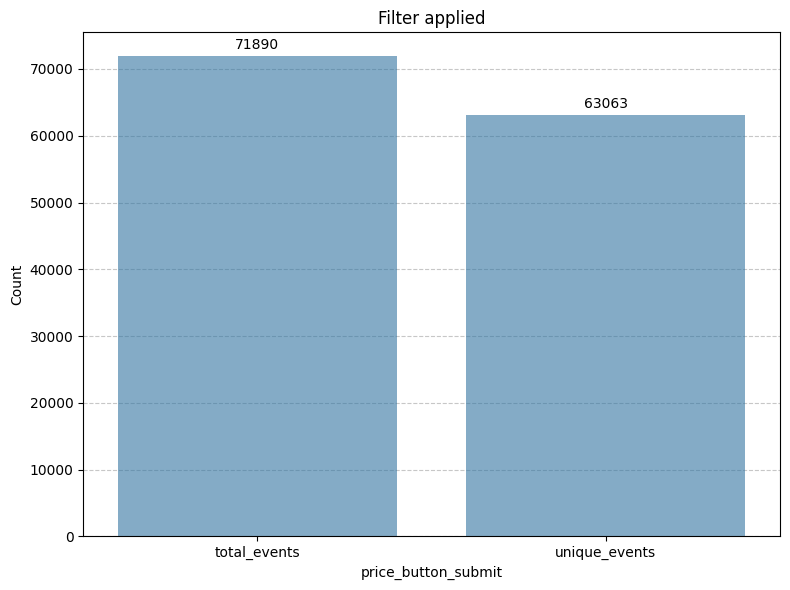

In [ ]:
filter_applied = data[data["event_action"] == "price_button_submit"]
plot_data = pd.DataFrame({
    'Metric': ['total_events', 'unique_events'],
    'Count': [
        filter_applied["total_events"].sum(),
        filter_applied["unique_events"].sum()
    ]
})


plt.figure(figsize=(8, 6))
ax = sns.barplot(data=plot_data, x='Metric', y='Count', alpha=0.6)
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=10)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.ylabel('Count')
plt.xlabel('price_button_submit')
plt.title('Вызов фильтра')
plt.tight_layout()
plt.show()

In [ ]:
len(data["city"].unique())

651

Имеем 651 город. Построим гистограмму для топ 10 по макс запросам. И 10 последних. 

In [99]:
df1 = data[data["event_action"] == "price_button_submit"]
cities = df1.groupby("city")["unique_events"].sum().sort_values()

In [100]:
print(cities)

city
Parma                  1
Marbella               1
San Francisco          1
Izborsk                1
Medellin               1
                    ... 
Istanbul            2357
Sochi               2909
Moscow              3176
Saint Petersburg    5028
Kaliningrad         5222
Name: unique_events, Length: 363, dtype: int64


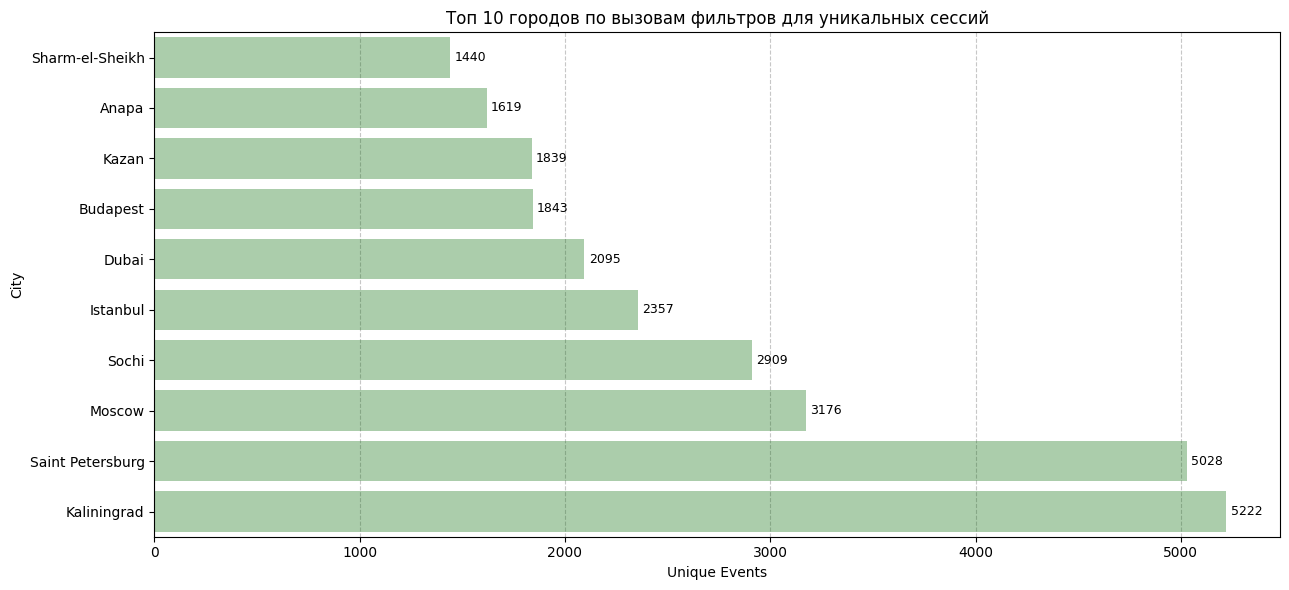

In [121]:
cities_df = cities[-10:].reset_index()
cities_df.columns = ['city', 'unique_events']

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=cities_df, 
                 y='city', 
                 x='unique_events', 
                 alpha=0.35, 
                 color="green")

ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=9)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.xlabel('Unique Events')
plt.ylabel('City')
plt.title('Топ 10 городов по вызовам фильтров для уникальных сессий')
plt.tight_layout()
plt.show()

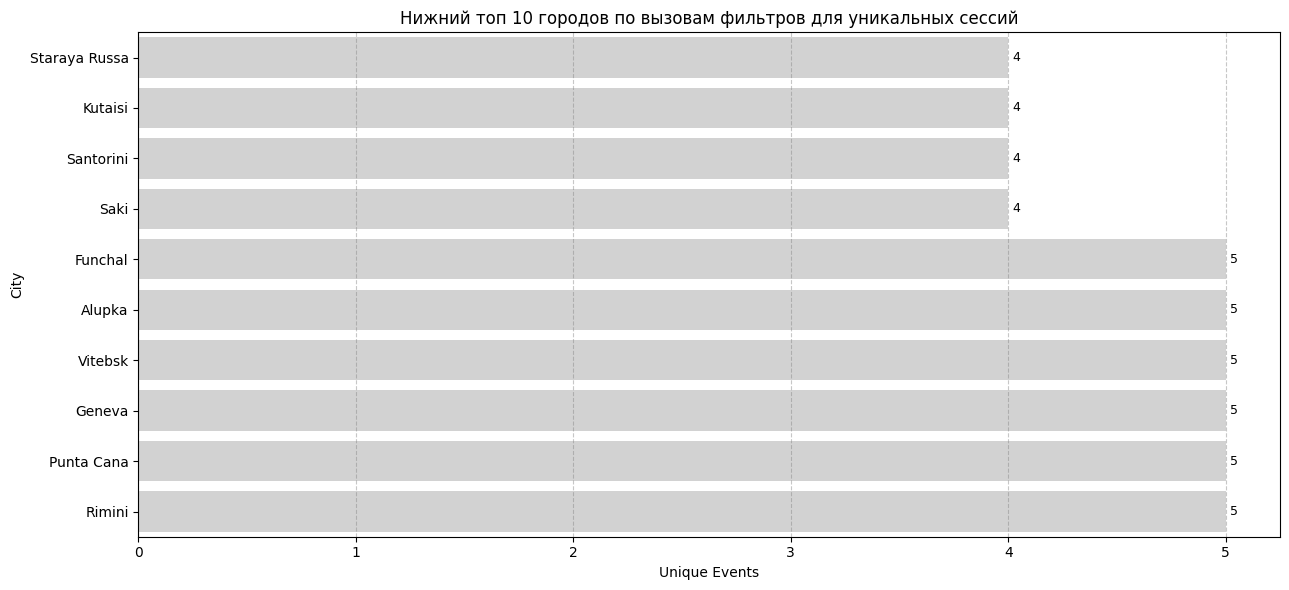

In [122]:
cities_df = cities[120:130].reset_index()
cities_df.columns = ['city', 'unique_events']

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=cities_df, 
                 y='city', 
                 x='unique_events', 
                 alpha=0.35, 
                 color="gray")

ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=9)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.xlabel('Unique Events')
plt.ylabel('City')
plt.title('Нижний топ 10 городов по вызовам фильтров для уникальных сессий')
plt.tight_layout()
plt.show()

### Визуализация по странам

Для анализа по странам необходимо сгруппировать города по странам. Ниже представлена визуализация топ стран по количеству уникальных событий (price_button_submit).

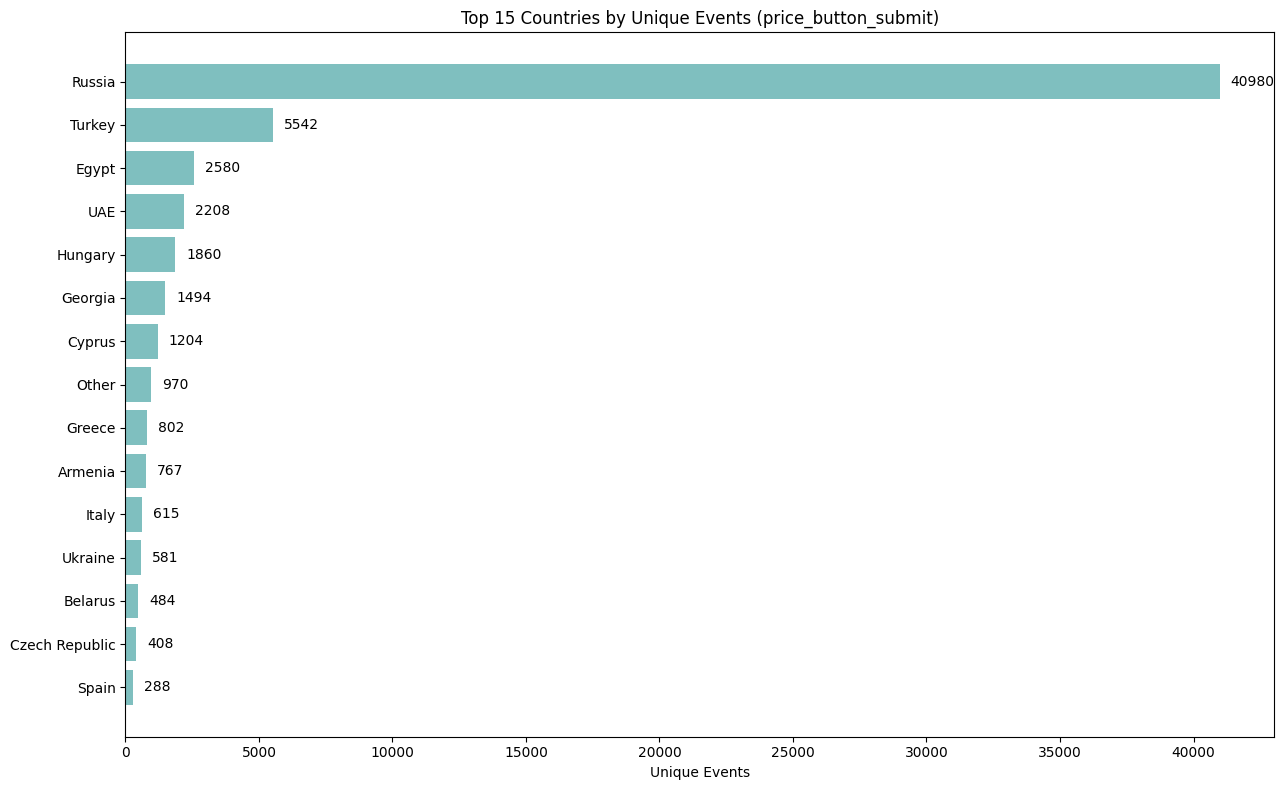

In [ ]:
from city_to_country import city_to_country

# Добавляем колонку со страной
data['country'] = data['city'].map(city_to_country).fillna('Other')

df2 = data[data['event_action'] == 'price_button_submit']
countries = df2.groupby('country')['unique_events'].sum().sort_values(ascending=False)

top_countries = countries.head(15)

plt.figure(figsize=(13, 8))
ax = plt.barh(range(len(top_countries)), top_countries.values, color='teal', alpha=0.5)
plt.yticks(range(len(top_countries)), top_countries.index)
plt.xlabel('Unique Events')
plt.title('Топ 15 стран по числу вызовов фильтров')
plt.gca().invert_yaxis()

for i, v in enumerate(top_countries.values):
    plt.text(v + max(top_countries.values)*0.01, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()

In [104]:
df3 = data[data['event_action'] == "filters-categories_click"]
df3.shape

(3352, 7)

### Классификация фильтров по типам

Разделяем event_label для `filters-categories_click` на 3 группы:
- **Фильтры** - параметры отбора (цена, рейтинг, дата, тип билета и т.д.)
- **Сортировка** - порядок отображения (по дешевизне, популярности и т.д.)
- **Категории** - тематические направления (обзорные, пешеходные, музеи и т.д.)

In [105]:
from feature_filter_classification import classify_filter

df3['filter_category'] = df3['event_label'].apply(classify_filter)
df3.head()


,event_category,event_action,event_label,total_events,unique_events,city,country,filter_category
3,city_landing,filters-categories_click,ЭКСКУРСИИ В ГЕЛЕНДЖИКЕ ЦЕНЫ,1,1,Gelendzhik,Russia,категории
9,city_landing,filters-categories_click,Необычные,3,3,Krakow,Poland,категории
11,city_landing,filters-categories_click,Сначала самые дешевые,62,50,Barcelona,Spain,сортировка
12,city_landing,filters-categories_click,Автобусные,42,32,Novorossiysk,Russia,категории
15,city_landing,filters-categories_click,Групповые,10,8,Sergiev Posad,Russia,фильтры


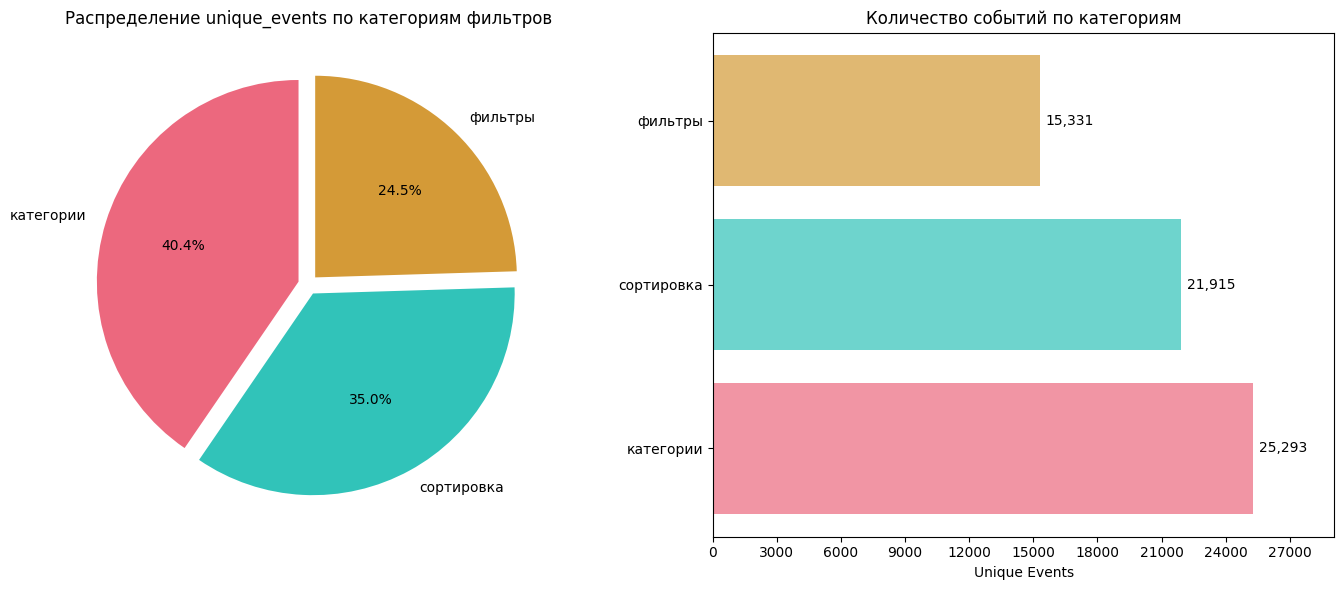

In [ ]:
category_stats = df3.groupby('filter_category')['unique_events'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#ec687e", "#31c3b9", "#d49a37"]
axes[0].pie(
    category_stats.values,
    labels=category_stats.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05, 0.05)
)
axes[0].set_title('Распределение unique_events по категориям фильтров')

bars = axes[1].barh(
    category_stats.index,
    category_stats.values,
    color=colors,
    alpha=0.7
)
max_val = category_stats.values.max()
padding = max_val * 0.15
axes[1].set_xlim(0, max_val + padding)
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].set_xlabel('Unique Events')
axes[1].set_title('Количество событий по категориям')

for bar, val in zip(bars, category_stats.values):
    axes[1].text(
        val + max(category_stats.values)*0.01,
        bar.get_y() + bar.get_height()/2,
        f'{int(val):,}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()


### Нормализация названий фильтров
Для визуализации самых популярных видов фильтров для трех категории выше потребовалось удалить дубликаты. 


Функция для устранения дубликатов типа:
- "Групповые" / "Групповая" / "групповые экскурсии"
- "Индивидуальные" / "Индивидуальная" / "индивидуальные экскурсии"
- "Пешеходные" / "Пешеходная экскурсия"
- "Автобусные" / "Автобусная экскурсия"

Приводит похожие названия к единому каноническому виду.

In [107]:
from feature_normalize_filters import normalize_filters_df

df3 = normalize_filters_df(df3)
df3.head()

,event_category,event_action,event_label,total_events,unique_events,city,country,filter_category,normalized_filter
3,city_landing,filters-categories_click,ЭКСКУРСИИ В ГЕЛЕНДЖИКЕ ЦЕНЫ,1,1,Gelendzhik,Russia,категории,ЭКСКУРСИИ В ГЕЛЕНДЖИКЕ ЦЕНЫ
9,city_landing,filters-categories_click,Необычные,3,3,Krakow,Poland,категории,Необычные экскурсии
11,city_landing,filters-categories_click,Сначала самые дешевые,62,50,Barcelona,Spain,сортировка,Сначала дешевые
12,city_landing,filters-categories_click,Автобусные,42,32,Novorossiysk,Russia,категории,Автобусные
15,city_landing,filters-categories_click,Групповые,10,8,Sergiev Posad,Russia,фильтры,Групповые


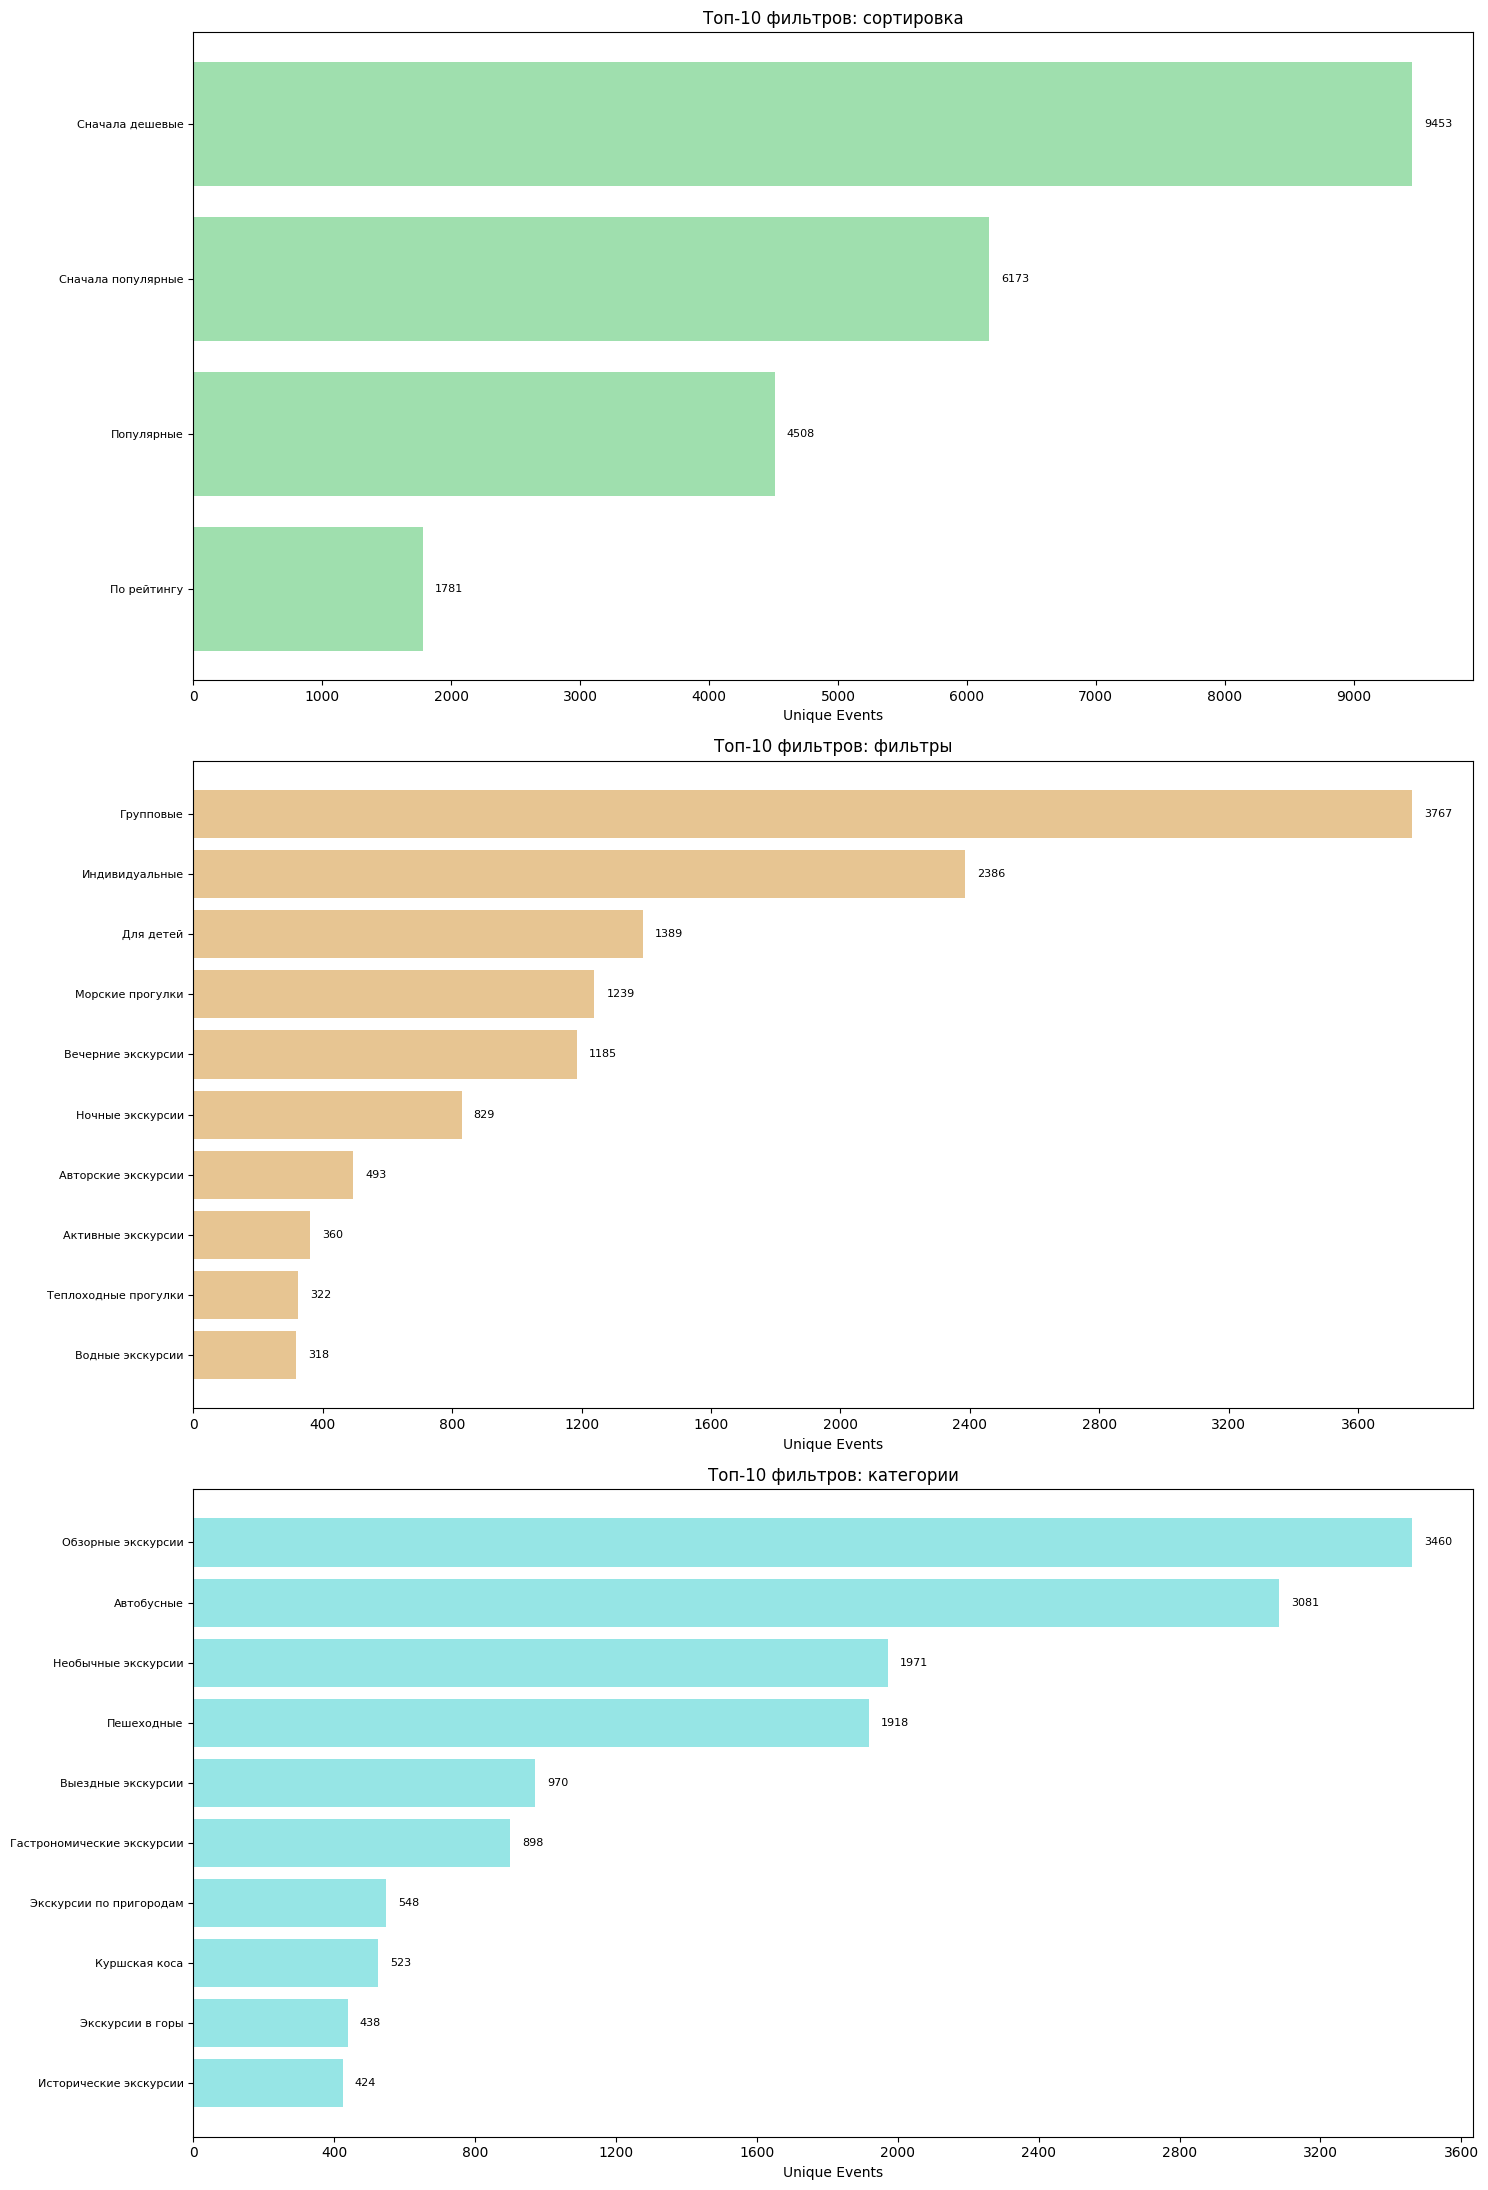

In [108]:
n = 10

fig, axes = plt.subplots(3, 1, figsize=(15, 22))
for idx, category in enumerate(['сортировка', 'фильтры', 'категории']):
    cat_data = df3[df3['filter_category'] == category].groupby('normalized_filter',as_index=False)["unique_events"].sum()
    cat_data.head()
    top_n = cat_data.nlargest(n, 'unique_events')
    
    axes[idx].barh(
        range(len(top_n)),
        top_n['unique_events'].values,
        color=["#41c05f", "#d08c27", "#2ecccc"][idx],
        alpha=0.5
    )
    axes[idx].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[idx].set_yticks(range(len(top_n)))
    axes[idx].set_yticklabels(top_n['normalized_filter'], fontsize=8)
    axes[idx].set_xlabel('Unique Events')
    axes[idx].set_title(f'Топ-{n} фильтров: {category}')
    axes[idx].invert_yaxis()
    
    for i, val in enumerate(top_n['unique_events'].values):
        axes[idx].text(
            val + max(top_n['unique_events'].values)*0.01,
            i,
            str(int(val)),
            va='center',
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [109]:
price_features = ["price_first", "price_second", "price_third"]

df4 = data[data["event_action"].isin(price_features)]
df4.head()

,event_category,event_action,event_label,total_events,unique_events,city,country
21,city_landing,price_third,NaN,6,4,Petrozavodsk,Russia
45,city_landing,price_third,NaN,186,94,Saint Petersburg,Russia
49,city_landing,price_second,NaN,3,1,Thessaloniki,Greece
132,city_landing,price_third,NaN,4,3,Makhachkala,Russia
253,city_landing,price_second,NaN,55,35,Kislovodsk,Russia


In [110]:
price_sm = df4.groupby("event_action", as_index=False)["unique_events"].sum()
price_sm.head()

,event_action,unique_events
0,price_first,6676
1,price_second,1995
2,price_third,595


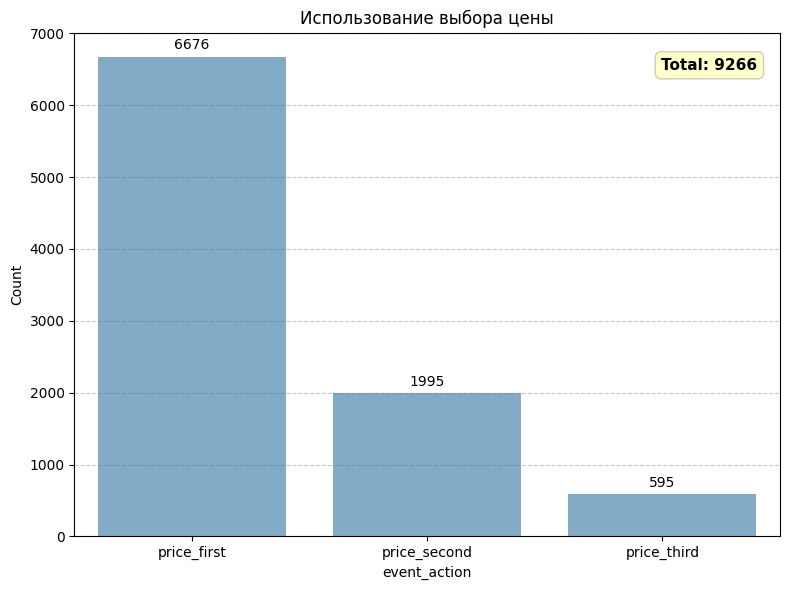

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=price_sm, x="event_action", y="unique_events", alpha=0.6)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.ylabel('Count')
plt.xlabel('event_action')
plt.title('Использование выбора цены')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

total = price_sm["unique_events"].sum()
plt.text(
    len(price_sm["event_action"].unique()) - 0.8,
    ax.get_ylim()[1] * 0.95,
    f'Total: {total:.0f}',
    ha='center', va='top',
    fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.2)
)

plt.tight_layout()
plt.show()